## Import Library

In [1]:
import os
import json
import zipfile
import platform
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

print(f"python : {platform.python_version()}")
print(f"numpy : {np.__version__}")
print(f"pandas : {pd.__version__}")
print(f"matplotlib : {matplotlib.__version__}")
print(f"random seed : {SEED}")

python : 3.12.13
numpy : 2.0.2
pandas : 2.3.3
matplotlib : 3.10.0
random seed : 42


## Konfigurasi Path Dataset

In [2]:
DATA_ROOT = "/kaggle/input/datasets/hiranomanabu/ransmap-2024-ransomware-behavioral-features/RanSMAP/dataset"
GROUPS = ["original", "extra", "variants", "mix"]
CSV_KINDS = ["ata_read", "ata_write", "mem_read", "mem_write", "mem_readwrite", "mem_exec"]

READ_TYPE_KINDS = ["ata_read", "mem_read", "mem_exec"] 
WRITE_TYPE_KINDS = ["ata_write", "mem_write", "mem_readwrite"]
ZERO_SIZE_KINDS = ["mem_read", "mem_exec"]

RANSOMWARE_CLASSES = {"Conti", "Darkside", "LockBit", "REvil", "Ryuk", "WannaCry"}
BENIGN_CLASSES = {"AESCrypt", "Firefox", "Idle", "Office", "SDelete", "Zip"}
SAMPLE_PER_CLASS = 5
EARLY_WINDOWS = [1, 2, 5, 10, 15, 20, 30, 60]

for g in GROUPS:
    assert os.path.isdir(os.path.join(DATA_ROOT, g)), f"Folder grup '{g}' tidak ditemukan di {DATA_ROOT}"
print("Semua 4 folder grup dataset (original, extra, variants, mix) terverifikasi ada.")

Semua 4 folder grup dataset (original, extra, variants, mix) terverifikasi ada.


## Membangun Manifest (Indeks Metadata, Tanpa Membaca Isi File)

In [3]:
def find_payload(run_dir, kind):
    csv_path = os.path.join(run_dir, f"{kind}.csv")
    zip_path = os.path.join(run_dir, f"{kind}.zip")
    if os.path.exists(csv_path):
        return csv_path, "csv"
    if os.path.exists(zip_path):
        return zip_path, "zip"
    return None, None


def walk_manifest(data_root, groups):
    rows = []
    for group in groups:
        group_dir = os.path.join(data_root, group)
        for cpu_dir in sorted(os.listdir(group_dir)):
            cpu_path = os.path.join(group_dir, cpu_dir)
            for hw_dir in sorted(os.listdir(cpu_path)):
                hw_path = os.path.join(cpu_path, hw_dir)
                for cls_dir in sorted(os.listdir(hw_path)):
                    cls_path = os.path.join(hw_path, cls_dir)
                    for run_name in sorted(os.listdir(cls_path)):
                        run_path = os.path.join(cls_path, run_name)
                        row = {"group": group, "cpu": cpu_dir, "hw": hw_dir,
                               "class": cls_dir, "run": run_name, "path": run_path}
                        total_bytes = 0
                        missing_kinds = []
                        for kind in CSV_KINDS:
                            p, ext = find_payload(run_path, kind)
                            row[f"{kind}_ext"] = ext
                            if p is None:
                                missing_kinds.append(kind)
                            else:
                                total_bytes += os.path.getsize(p)
                        row["total_bytes"] = total_bytes
                        row["n_missing_kinds"] = len(missing_kinds)
                        rows.append(row)
    return pd.DataFrame(rows)


manifest = walk_manifest(DATA_ROOT, GROUPS)
manifest.to_csv("/kaggle/working/manifest.csv", index=False)

print("=== RINGKASAN MANIFEST ===")
print(f"Jumlah eksekusi terindeks : {len(manifest)}")
print(f"Eksekusi dengan berkas hilang (n_missing_kinds > 0): {(manifest['n_missing_kinds'] > 0).sum()}")
print(f"Total ukuran dataset di disk: {manifest['total_bytes'].sum() / 1e9:.2f} GB")
print(f"Disimpan ke: /kaggle/working/manifest.csv")


=== RINGKASAN MANIFEST ===
Jumlah eksekusi terindeks : 1970
Eksekusi dengan berkas hilang (n_missing_kinds > 0): 1
Total ukuran dataset di disk: 172.08 GB
Disimpan ke: /kaggle/working/manifest.csv


In [4]:
incomplete = manifest[manifest["n_missing_kinds"] > 0]
n_incomplete = len(incomplete)

print("\n=== Jumlah eksekusi tidak lengkap per (group, class) ===")
print(incomplete.groupby(["group", "class"]).size().sort_values(ascending=False).to_string())

print("\n=== Jenis berkas yang hilang, dan pada berapa eksekusi ===")
for kind in CSV_KINDS:
    missing_this_kind = incomplete[incomplete[f"{kind}_ext"].isna()]
    if len(missing_this_kind) > 0:
        print(f"  {kind:15s}: hilang pada {len(missing_this_kind)} eksekusi")


=== Jumlah eksekusi tidak lengkap per (group, class) ===
group     class  
original  LockBit    1

=== Jenis berkas yang hilang, dan pada berapa eksekusi ===
  ata_read       : hilang pada 1 eksekusi


## Verifikasi Skema Kolom

In [5]:
sample_run = manifest[manifest.group == "original"].sample(1, random_state=SEED).iloc[0]
print(f"Eksekusi sampel untuk verifikasi skema: {sample_run['path']}")
print()

raw_field_counts = {}
for kind in CSV_KINDS:
    path, ext = find_payload(sample_run["path"], kind)
    if ext == "csv":
        with open(path, "r") as f:
            first_line = f.readline().strip()
    else:
        with zipfile.ZipFile(path) as z:
            inner = [n for n in z.namelist() if n.endswith(".csv")][0]
            with z.open(inner) as f:
                first_line = f.readline().decode().strip()
    fields = [x.strip() for x in first_line.split(",")]
    raw_field_counts[kind] = len(fields)
    print(f"{kind:15s} ({ext}) -> {len(fields)} kolom -> {fields}")


Eksekusi sampel untuk verifikasi skema: /kaggle/input/datasets/hiranomanabu/ransmap-2024-ransomware-behavioral-features/RanSMAP/dataset/original/celeron-gen6/ddr4-1600-8g/Idle/Idle-20231004_14-23-44

ata_read        (csv) -> 6 kolom -> ['1696396759', '977782424', '29677050', '4096', '-1', '0']
ata_write       (csv) -> 6 kolom -> ['1696396758', '776507902', '95424216', '4096', '0.9059465309529979', '0']
mem_read        (csv) -> 6 kolom -> ['1696396758', '550237719', '8374919040', '0', '-1', '2']
mem_write       (csv) -> 6 kolom -> ['1696396758', '551500155', '7719792008', '4096', '0.8559991757088737', '2']
mem_readwrite   (csv) -> 6 kolom -> ['1696396758', '570113571', '9683569584', '4096', '0.712781994614056', '2']
mem_exec        (csv) -> 6 kolom -> ['1696396758', '550303202', '45352848', '0', '-1', '2']


In [6]:
COLS = ["t_s", "t_ns", "addr", "size", "entropy", "type"]

assert all(v == 6 for v in raw_field_counts.values()), (
    f"Skema kolom tidak seragam 6 kolom pada seluruh jenis berkas: {raw_field_counts}. "
    f"Sesuaikan definisi COLS sebelum melanjutkan ke notebook berikutnya."
)
print("[OK] Skema 6-kolom terkonfirmasi seragam untuk seluruh jenis berkas CSV RanSMAP.")


def load_csv_safe(path, ext, usecols=None, nrows=None):
    names = COLS if usecols is None else [COLS[i] for i in usecols]
    if ext == "csv":
        return pd.read_csv(path, header=None, names=names, usecols=usecols, nrows=nrows)
    with zipfile.ZipFile(path) as z:
        inner = [n for n in z.namelist() if n.endswith(".csv")][0]
        with z.open(inner) as f:
            return pd.read_csv(f, header=None, names=names, usecols=usecols, nrows=nrows)


[OK] Skema 6-kolom terkonfirmasi seragam untuk seluruh jenis berkas CSV RanSMAP.


## Verifikasi Nilai & Durasi Eksekusi

In [7]:
rng_sample = manifest.groupby("group", group_keys=False).apply(
    lambda g: g.sample(min(3, len(g)), random_state=SEED), include_groups=False
)
rng_sample = manifest.loc[rng_sample.index]

integrity_rows = []
for _, run in rng_sample.iterrows():
    for kind in CSV_KINDS:
        path, ext = find_payload(run["path"], kind)
        df = load_csv_safe(path, ext)
        t = df["t_s"] + df["t_ns"] / 1e9
        row = {
            "group": run["group"], "class": run["class"], "kind": kind, "ext": ext,
            "n_rows": len(df),
            "duration_s": (t.iloc[-1] - t.iloc[0]) if len(df) > 1 else np.nan,
            "monotonic": bool((t.diff().dropna() >= 0).all()) if len(df) > 1 else True,
        }
        if kind in READ_TYPE_KINDS:
            row["entropy_ok"] = bool((df["entropy"] == -1).all())
        else:
            row["entropy_ok"] = bool(df["entropy"].between(0, 1).all())
        if kind in ZERO_SIZE_KINDS:
            row["size_ok"] = bool((df["size"] == 0).all())
        else:
            row["size_ok"] = True
        integrity_rows.append(row)

integrity = pd.DataFrame(integrity_rows)

print("=== RINGKASAN VERIFIKASI INTEGRITAS ===")
print(f"Jumlah berkas diperiksa           : {len(integrity)}")
print(f"Timestamp monoton (non-decreasing): {integrity['monotonic'].sum()} / {len(integrity)}")
print(f"Nilai entropy sesuai spesifikasi  : {integrity['entropy_ok'].sum()} / {len(integrity)}")
print(f"Nilai size sesuai spesifikasi     : {integrity['size_ok'].sum()} / {len(integrity)}")
print(f"Berkas berformat .zip ditemukan   : {(integrity['ext'] == 'zip').sum()} / {len(integrity)}")

print("\n=== Rincian per jenis berkas (untuk menelusuri penyimpangan bila ada) ===")
breakdown = integrity.groupby("kind")[["monotonic", "entropy_ok", "size_ok"]].mean().round(3)
print(breakdown.to_string())

dur = integrity.loc[integrity["kind"] == "ata_write", "duration_s"].dropna()
print(f"\nDurasi eksekusi (dari ata_write.csv), n={len(dur)}:")
print(f"  min={dur.min():.1f}s | mean={dur.mean():.1f}s | max={dur.max():.1f}s")
print(f"  Eksekusi berdurasi < 30 detik: {(dur < 30).sum()} / {len(dur)}")


=== RINGKASAN VERIFIKASI INTEGRITAS ===
Jumlah berkas diperiksa           : 72
Timestamp monoton (non-decreasing): 72 / 72
Nilai entropy sesuai spesifikasi  : 72 / 72
Nilai size sesuai spesifikasi     : 64 / 72
Berkas berformat .zip ditemukan   : 0 / 72

=== Rincian per jenis berkas (untuk menelusuri penyimpangan bila ada) ===
               monotonic  entropy_ok  size_ok
kind                                         
ata_read             1.0         1.0    1.000
ata_write            1.0         1.0    1.000
mem_exec             1.0         1.0    1.000
mem_read             1.0         1.0    0.333
mem_readwrite        1.0         1.0    1.000
mem_write            1.0         1.0    1.000

Durasi eksekusi (dari ata_write.csv), n=12:
  min=179.6s | mean=190.9s | max=201.7s
  Eksekusi berdurasi < 30 detik: 0 / 12


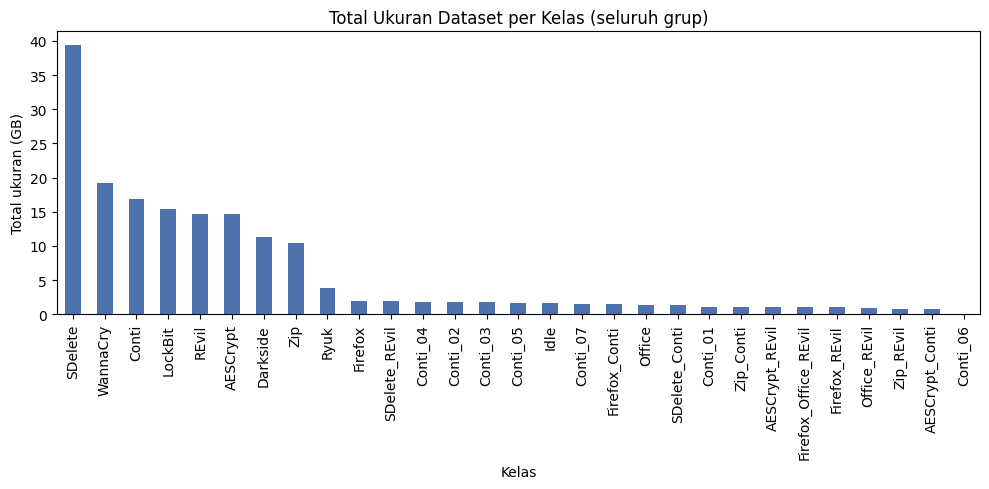

=== Ukuran dataset per kelas (GB) ===
class
SDelete                 39.42
WannaCry                19.25
Conti                   16.83
LockBit                 15.35
REvil                   14.72
AESCrypt                14.62
Darkside                11.33
Zip                     10.44
Ryuk                     3.87
Firefox                  1.98
SDelete_REvil            1.88
Conti_04                 1.86
Conti_02                 1.83
Conti_03                 1.80
Conti_05                 1.71
Idle                     1.59
Conti_07                 1.55
Firefox_Conti            1.46
Office                   1.35
SDelete_Conti            1.31
Conti_01                 1.13
Zip_Conti                1.13
AESCrypt_REvil           1.01
Firefox_Office_REvil     1.00
Firefox_REvil            0.99
Office_REvil             0.91
Zip_REvil                0.84
AESCrypt_Conti           0.83
Conti_06                 0.10


In [8]:
size_by_class = manifest.groupby("class")["total_bytes"].sum().sort_values(ascending=False) / 1e9

fig, ax = plt.subplots(figsize=(10, 5))
size_by_class.plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_ylabel("Total ukuran (GB)")
ax.set_xlabel("Kelas")
ax.set_title("Total Ukuran Dataset per Kelas (seluruh grup)")
plt.tight_layout()
plt.show()

print("=== Ukuran dataset per kelas (GB) ===")
print(size_by_class.round(2).to_string())


## Distribusi Kelas & Perangkat Keras

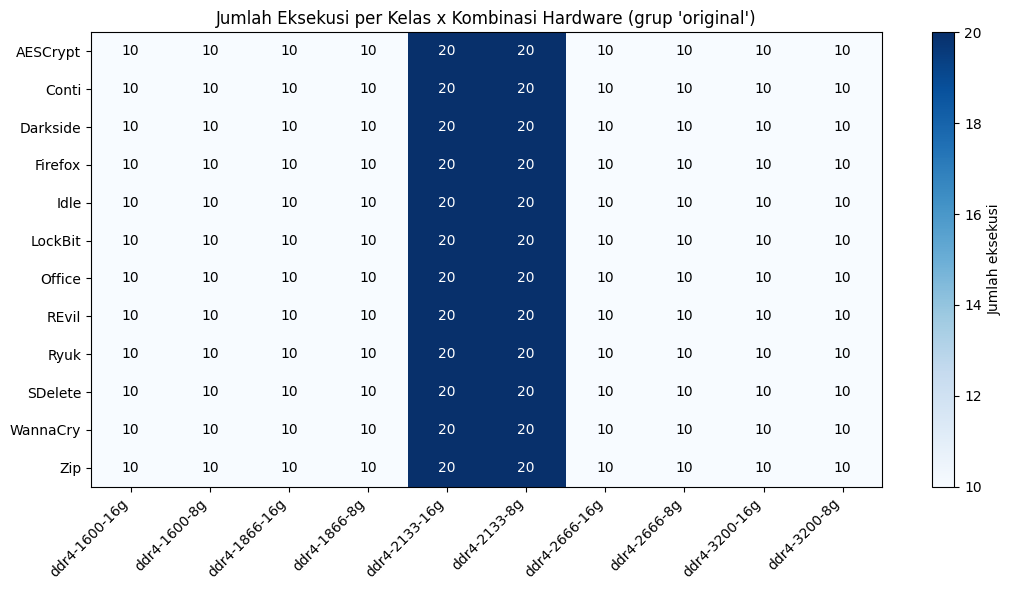

In [9]:
pivot = manifest[manifest.group == "original"].pivot_table(
    index="class", columns="hw", values="run", aggfunc="count", fill_value=0
)

fig, ax = plt.subplots(figsize=(11, 6))
im = ax.imshow(pivot.values, cmap="Blues", aspect="auto")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=45, ha="right")
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_title("Jumlah Eksekusi per Kelas x Kombinasi Hardware (grup 'original')")
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, pivot.values[i, j], ha="center", va="center",
                color="white" if pivot.values[i, j] > pivot.values.max() / 2 else "black")
fig.colorbar(im, ax=ax, label="Jumlah eksekusi")
plt.tight_layout()
plt.show()


## Temuan Pendahuluan: Profil Window-Awal (Ilustratif)

In [10]:
orig = manifest[manifest.group == "original"]
profile_rows = []

for cls, g in orig.groupby("class"):
    picks = g.sample(min(SAMPLE_PER_CLASS, len(g)), random_state=SEED)
    for _, run in picks.iterrows():
        p_ata, ext_ata = find_payload(run["path"], "ata_write")
        p_mem, ext_mem = find_payload(run["path"], "mem_write")
        df_ata = load_csv_safe(p_ata, ext_ata)
        df_mem = load_csv_safe(p_mem, ext_mem)

        t0_ata = df_ata["t_s"].iloc[0] + df_ata["t_ns"].iloc[0] / 1e9
        df_ata = df_ata.assign(t_rel=(df_ata["t_s"] + df_ata["t_ns"] / 1e9) - t0_ata)
        t0_mem = df_mem["t_s"].iloc[0] + df_mem["t_ns"].iloc[0] / 1e9
        df_mem = df_mem.assign(t_rel=(df_mem["t_s"] + df_mem["t_ns"] / 1e9) - t0_mem)

        for w in EARLY_WINDOWS:
            a = df_ata[df_ata["t_rel"] < w]
            m = df_mem[df_mem["t_rel"] < w]
            profile_rows.append({
                "class": cls,
                "is_ransomware": cls in RANSOMWARE_CLASSES,
                "window_s": w,
                "ata_write_ops": len(a),
                "ata_mean_entropy": a["entropy"].mean() if len(a) else np.nan,
                "mem_write_ops": len(m),
                "mem_mean_entropy": m["entropy"].mean() if len(m) else np.nan,
            })

profile = pd.DataFrame(profile_rows)
print(f"Profil terkumpul: {len(profile)} baris ({profile['class'].nunique()} kelas x {len(EARLY_WINDOWS)} window x sampel/kelas)")


Profil terkumpul: 480 baris (12 kelas x 8 window x sampel/kelas)


In [11]:
w_show = 5
print(f"=== Rata-rata per kelas pada window = {w_show} detik pertama (diurutkan menurun) ===")
tbl = (profile[profile.window_s == w_show]
       .groupby(["class", "is_ransomware"])[["ata_write_ops", "ata_mean_entropy", "mem_write_ops", "mem_mean_entropy"]]
       .mean()
       .sort_values("ata_write_ops", ascending=False))
print(tbl.round(3).to_string())


=== Rata-rata per kelas pada window = 5 detik pertama (diurutkan menurun) ===
                        ata_write_ops  ata_mean_entropy  mem_write_ops  mem_mean_entropy
class    is_ransomware                                                                  
SDelete  False                22367.6             0.378         5272.8             0.015
Zip      False                 3211.8             0.615         3214.2             0.027
Darkside True                  2930.0             0.452         8080.0             0.027
Firefox  False                 2222.2             0.473         3448.0             0.040
AESCrypt False                 2113.4             0.648         9382.6             0.013
Idle     False                 1874.2             0.651         1164.6             0.065
REvil    True                  1864.0             0.574         6499.4             0.027
WannaCry True                  1394.0             0.528         2743.4             0.042
Conti    True                  1

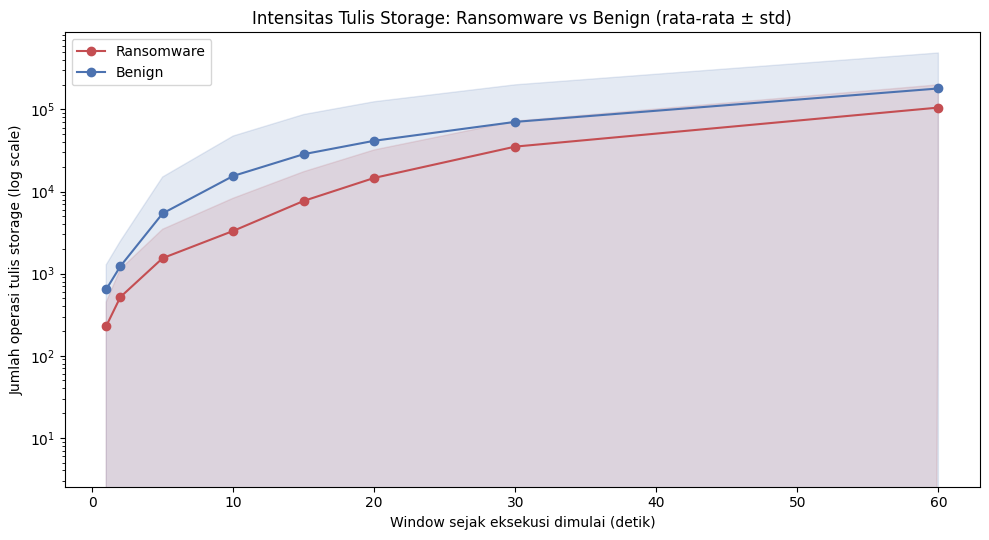

In [12]:
agg = profile.groupby(["is_ransomware", "window_s"])["ata_write_ops"].agg(["mean", "std"]).reset_index()

fig, ax = plt.subplots(figsize=(10, 5.5))
for is_r, label, color in [(True, "Ransomware", "#C44E52"), (False, "Benign", "#4C72B0")]:
    sub = agg[agg.is_ransomware == is_r].sort_values("window_s")
    ax.plot(sub["window_s"], sub["mean"], marker="o", label=label, color=color)
    ax.fill_between(sub["window_s"], sub["mean"] - sub["std"].fillna(0),
                     sub["mean"] + sub["std"].fillna(0), alpha=0.15, color=color)
ax.set_yscale("log")
ax.set_xlabel("Window sejak eksekusi dimulai (detik)")
ax.set_ylabel("Jumlah operasi tulis storage (log scale)")
ax.set_title("Intensitas Tulis Storage: Ransomware vs Benign (rata-rata ± std)")
ax.legend()
plt.tight_layout()
plt.show()